In [1]:
from sklearn.model_selection import train_test_split
import pandas as pd
from random_forest_regression import RandomForestModel
from probabilistic_rf_scoring import select_best_pdf_one_sample,plot_best_pdf
import joblib
import os

In [2]:
TRAIN_SPLIT=0.85
TEST_SPLIT=0.15
TARGET_COL = "trq_margin"
TRAIN_PATH_X = "../../../data/processed/train/train_trqMargin.csv"
OUTPUT_PATH="../../../output/random_forest_regressor/model_margin/"
MODEL_PATH="random_forest_model_margin.pkl"
METRIC_TRAIN="metric_train.csv"
METRIC_TEST="metric_test.csv"

In [4]:
train_data = pd.read_csv(TRAIN_PATH_X)
train_df, test_df = train_test_split(
    train_data,
    test_size=TEST_SPLIT,
    random_state=42,
    shuffle=True
)
drop_cols = [TARGET_COL]
X_cols = [c for c in train_df.columns if c not in drop_cols]

X_train = train_df[X_cols].values
y_train = train_df[TARGET_COL].values

X_test = test_df[X_cols].values
y_test = test_df[TARGET_COL].values

In [5]:
rf_model = RandomForestModel(
    n_estimators=500,
    min_samples_leaf=5
)
if os.path.exists(OUTPUT_PATH+MODEL_PATH):
    rf_model=joblib.load(OUTPUT_PATH+MODEL_PATH)
else:
    rf_model.fit(X_train, y_train)
    joblib.dump(rf_model, OUTPUT_PATH + MODEL_PATH)

In [6]:
metric_train=rf_model.evaluate(X_train, y_train,"train")
df_metric_train = pd.DataFrame([metric_train])
df_metric_train.to_csv(OUTPUT_PATH+METRIC_TRAIN, index=False)

metric_validate=rf_model.evaluate(X_test, y_test,"test")
df_metric_test = pd.DataFrame([metric_validate])
df_metric_test.to_csv(OUTPUT_PATH+METRIC_TEST, index=False)


Metrics on train
MAE  : 0.313295
RMSE : 0.558170
R²   : 0.998420

Metrics on test
MAE  : 0.436675
RMSE : 0.762892
R²   : 0.997123


In [7]:
row = test_df.iloc[332]
x0 = row[X_cols].to_numpy().reshape(1, -1)
y_true =row[TARGET_COL]
mean_pred = rf_model.predict_mean(x0)
tree_preds = rf_model.predict_trees(x0)
mu, sigma = rf_model.predict_distribution_stats(x0)

mean_pred, mu, sigma, tree_preds.shape

(array([0.67799478]), array([0.67799478]), array([0.43455336]), (1, 500))

In [8]:
best, ranking, tree_preds = select_best_pdf_one_sample(rf_model, x0, y_true)
print("BEST:", best)
for r in ranking:
    print(r["pdf_type"], r["score"])

BEST: {'pdf_type': 'norm', 'score': 0.8848338689418399, 'pdf_args': {'loc': 0.677994784339337, 'scale': 0.43455336229703234, 'args': ()}, 'loc': 0.677994784339337, 'scale': 0.43455336229703234, 'shape_params': ()}
norm 0.8848338689418399


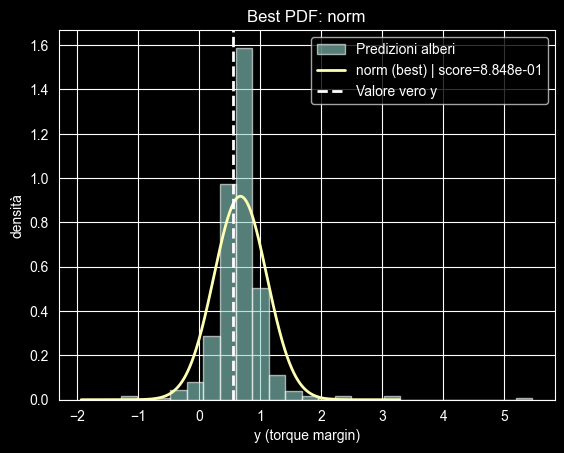

In [9]:
plot_best_pdf(best, tree_preds, y_true)